In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
df = pd.read_csv('/content/processed_data.csv')
df.head()

,fare_amount,distance_km,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour
0,7.5,1.683,-73.999817,40.738354,-73.999512,40.723217,1.0,2015.0,5.0,7.0,19.0
1,7.7,2.458,-73.994355,40.728225,-73.994710,40.750325,1.0,2009.0,7.0,17.0,20.0
2,12.9,5.036,-74.005043,40.740770,-73.962565,40.772647,1.0,2009.0,8.0,24.0,21.0
3,5.3,1.662,-73.976124,40.790844,-73.965316,40.803349,3.0,2009.0,6.0,26.0,8.0
4,16.0,4.475,-73.925023,40.744085,-73.973082,40.761247,5.0,2014.0,8.0,28.0,17.0


In [ ]:
df.shape


(78565, 11)

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78565 entries, 0 to 78564
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fare_amount        78565 non-null  float64
 1   distance_km        78565 non-null  float64
 2   pickup_longitude   78565 non-null  float64
 3   pickup_latitude    78565 non-null  float64
 4   dropoff_longitude  78565 non-null  float64
 5   dropoff_latitude   78565 non-null  float64
 6   passenger_count    78564 non-null  float64
 7   year               78564 non-null  float64
 8   month              78564 non-null  float64
 9   day                78564 non-null  float64
 10  hour               78564 non-null  float64
dtypes: float64(11)
memory usage: 6.6 MB


In [ ]:
df.describe()


,fare_amount,distance_km,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour
count,78565.000000,78565.000000,78565.000000,78565.000000,78565.000000,78565.000000,78564.000000,78564.000000,78564.000000,78564.000000,78564.000000
mean,8.167679,2.082479,-73.910373,40.685116,-73.909546,40.685198,1.682565,2011.735515,6.251209,15.683583,13.605735
std,3.356707,1.177898,2.790385,2.737746,2.790330,2.737797,1.298869,1.867822,3.447900,8.693247,6.381319
min,2.500000,0.000000,-75.342904,-74.009697,-75.350437,-74.009465,1.000000,2009.000000,1.000000,1.000000,0.000000
25%,5.700000,1.155000,-73.992225,40.738230,-73.991753,40.738329,1.000000,2010.000000,3.000000,8.000000,9.000000
50%,7.500000,1.835000,-73.982388,40.753620,-73.981642,40.753940,1.000000,2012.000000,6.000000,16.000000,14.000000
75%,10.000000,2.826000,-73.970587,40.766696,-73.969723,40.767042,2.000000,2013.000000,9.000000,23.000000,19.000000
max,22.100000,5.147000,40.808425,45.031653,40.802727,45.031598,6.000000,2015.000000,12.000000,31.000000,23.000000


In [ ]:
df.isnull().sum()


,0
fare_amount,0
distance_km,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,0
dropoff_latitude,0
passenger_count,1
year,1
month,1
day,1


In [ ]:
df = df.dropna()   # simple approach


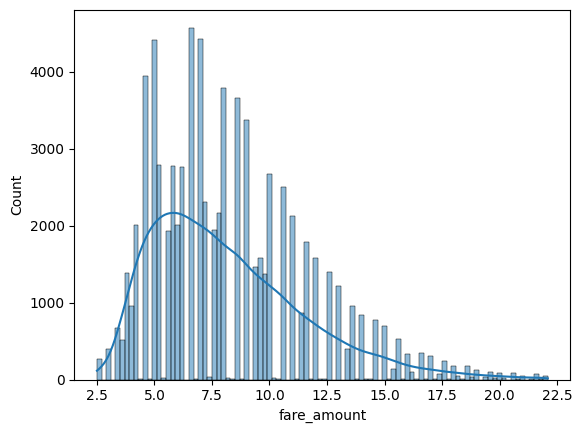

In [ ]:
sns.histplot(df['fare_amount'], kde=True)
plt.show()


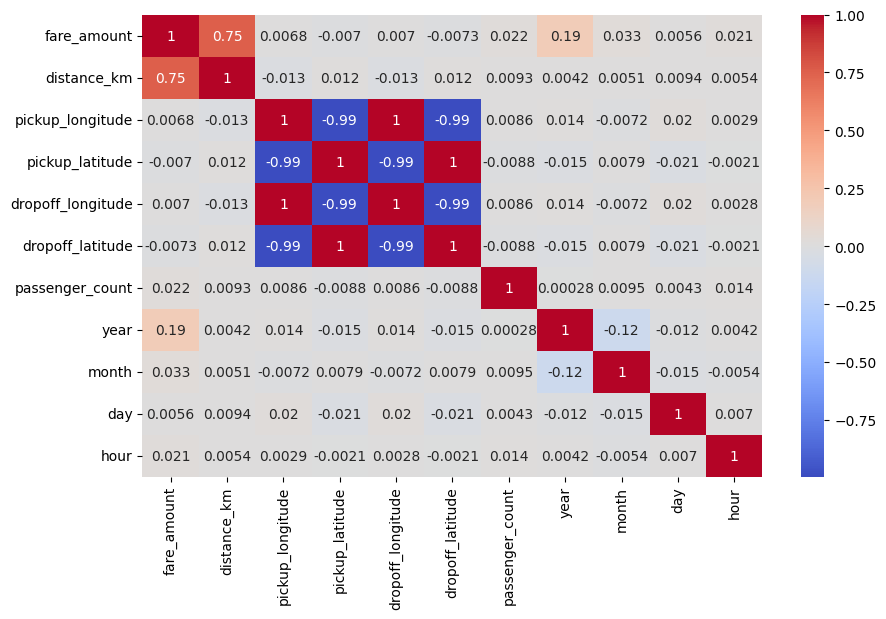

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()


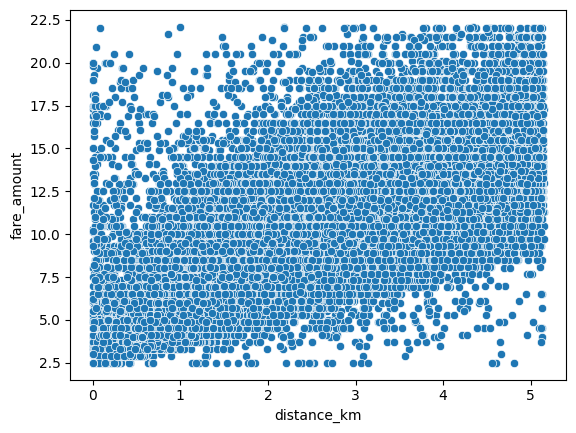

In [ ]:
sns.scatterplot(x=df['distance_km'], y=df['fare_amount'])
plt.show()

In [ ]:
X = df.drop('fare_amount', axis=1)
y = df['fare_amount']


In [ ]:
X = pd.get_dummies(X, drop_first=True)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [ ]:
y_pred = model.predict(X_test)


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


MAE: 1.4824524523823228
MSE: 4.3903470534181155
RMSE: 2.0953155021185035
R2 Score: 0.61346893811096


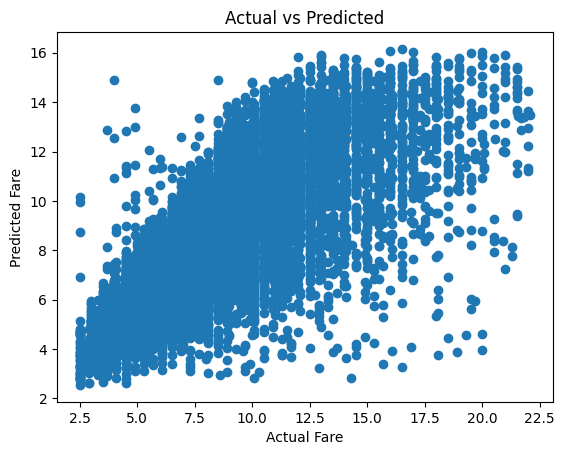

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted")
plt.show()


In [ ]:
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coeff_df.sort_values(by='Coefficient', ascending=False)


,Feature,Coefficient
2,pickup_latitude,8.501714
0,distance_km,2.146029
3,dropoff_longitude,0.945691
6,year,0.348714
7,month,0.048311
5,passenger_count,0.035208
9,hour,0.009018
8,day,0.000471
1,pickup_longitude,-0.846301
4,dropoff_latitude,-8.413480
